In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


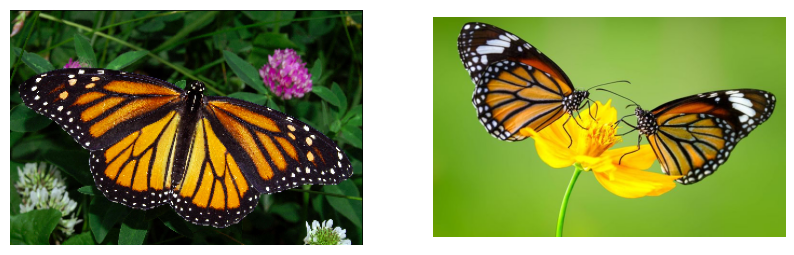

In [1]:
import torch
from torchvision.io import read_image
import matplotlib.pyplot as plt

# Function to load and preprocess images
def load_images(image_paths):
    images = []
    for path in image_paths:
        img = read_image(path)
        images.append(img)
    return images

# Function to display images
def display_images(images):
    plt.figure(figsize=(10, 5))
    for i, image in enumerate(images, 1):
        plt.subplot(1, len(images), i)
        plt.imshow(image.permute(1, 2, 0))
        plt.axis('off')
    plt.show()

# Load and display images
image_paths = ["/content/drive/MyDrive/data/cv2/image1.jpg", "/content/drive/MyDrive/data/cv2/image2.jpg"]
images = load_images(image_paths)
display_images(images)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


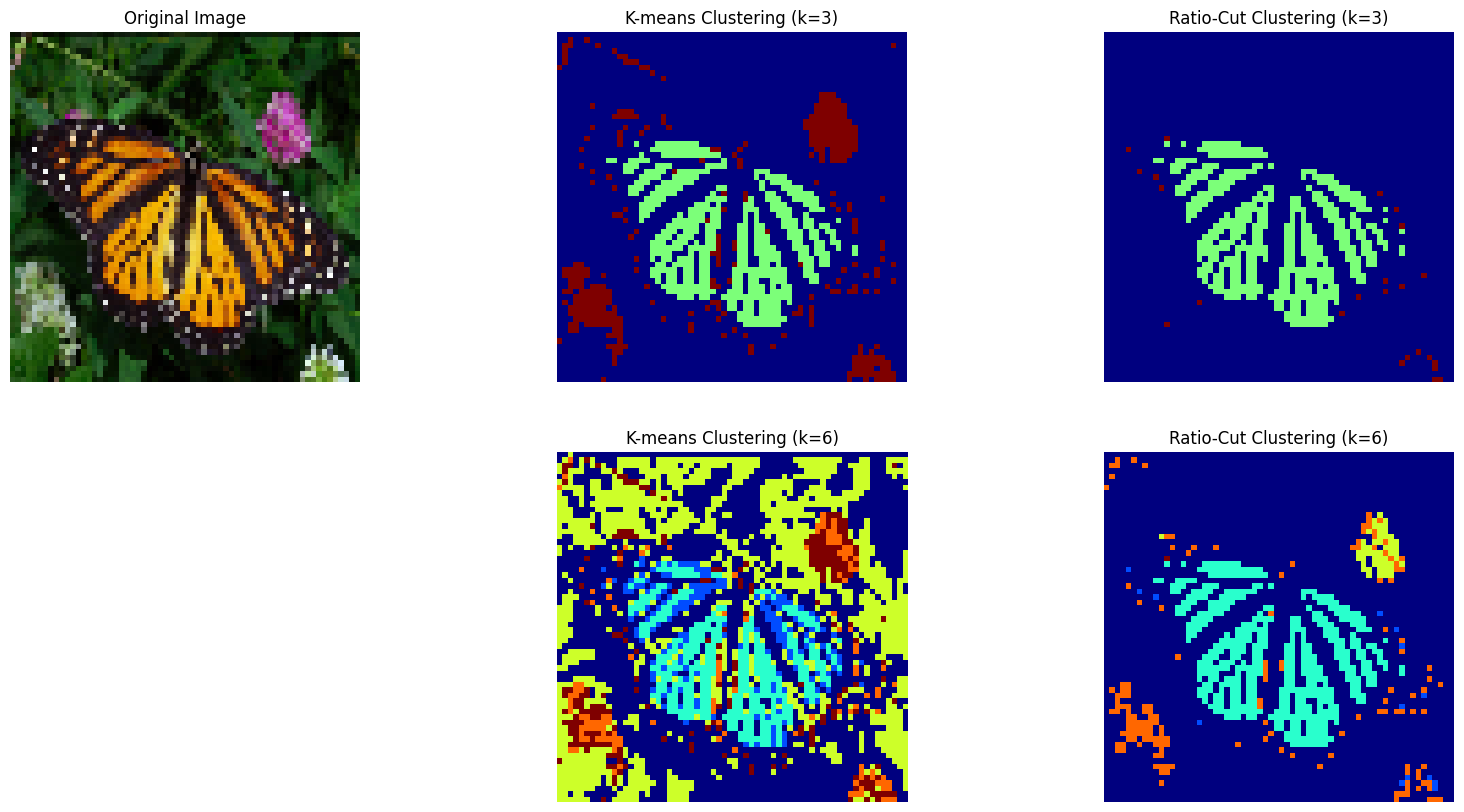

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


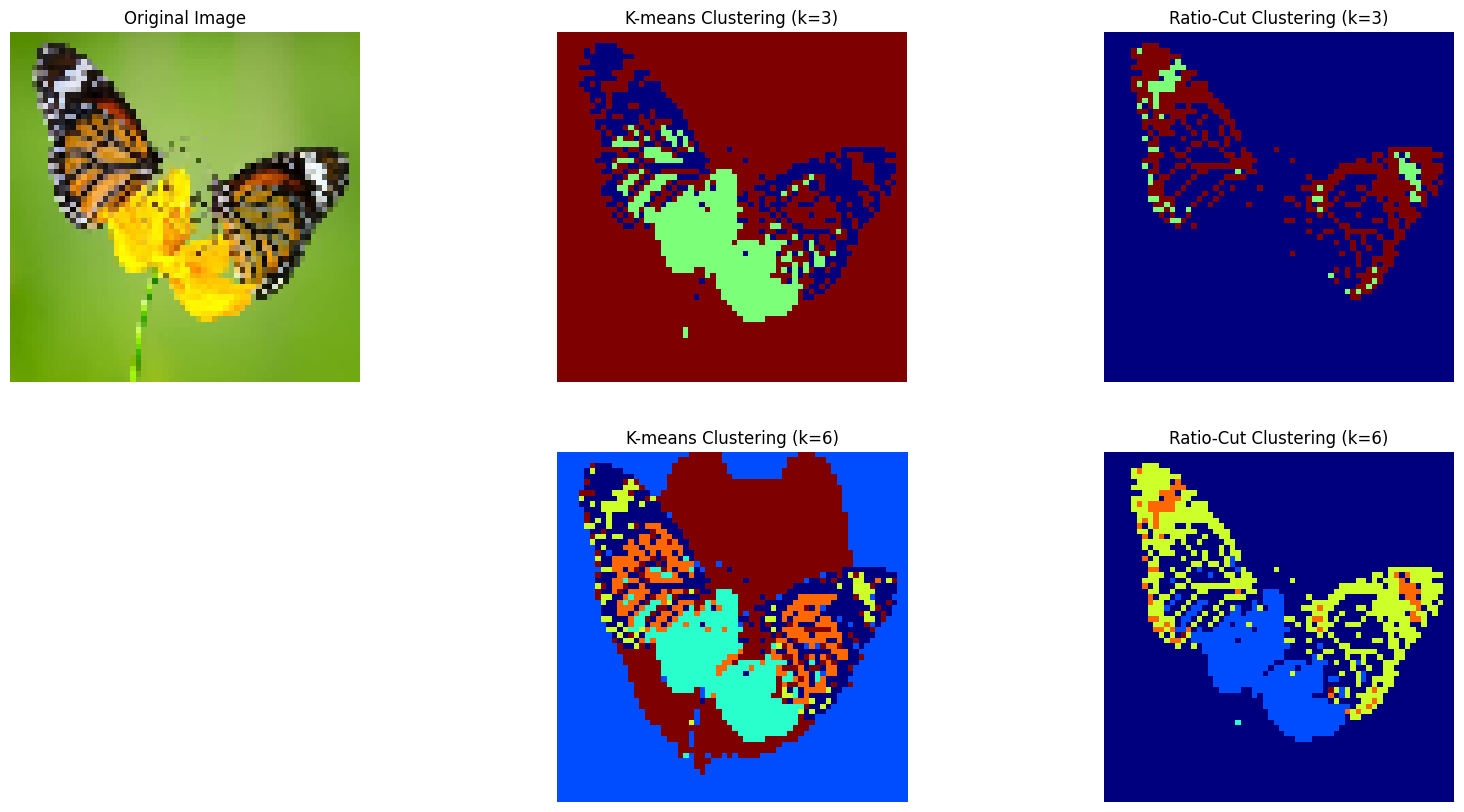

In [34]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import os
import torch
from torchvision.io import read_image
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow

# Function to load and preprocess images
def load_images(image_paths):
    images = []
    for path in image_paths:
        img = read_image(path)
        images.append(img)
    return images
def resize_image(image):
    # Convert the torch tensor to a NumPy array
    image_np = image.permute(1, 2, 0).numpy()
    # Resize the image to 64x64
    resized_image = cv2.resize(image_np, (64, 64))
    return resized_image

def ratio_cut_clustering(image, k, sigma=25):
    # Flatten the image to a 2D array
    pixels = image.reshape((-1, 3)).astype(np.float32)

    # Compute pairwise distance matrix
    pairwise_distances = np.linalg.norm(pixels[:, None] - pixels, axis=2)

    # Compute affinity matrix using Gaussian kernel
    affinity_matrix = np.exp(-pairwise_distances ** 2 / (2.0 * sigma ** 2))

    # Compute degree matrix
    degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))

    # Compute Laplacian matrix
    laplacian_matrix = degree_matrix - affinity_matrix
    #print(laplacian_matrix)


    # Compute eigenvalues and eigenvectors of Laplacian matrix
    eigenvalues, eigenvectors = np.linalg.eigh(laplacian_matrix)

    # Sort eigenvectors based on eigenvalues
    sorted_indices = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:, sorted_indices]


    # Use k smallest eigenvectors as features for clustering
    features = eigenvectors[:, :k]

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0).fit(features)
    labels = kmeans.labels_

    # Reshape labels to match image dimensions
    segmented_image = labels.reshape((64, 64))

    return segmented_image

def kmeans_clustering(image, k):
    # Flatten the image to a 2D array
    pixels = image.reshape((-1, 3))

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pixels)
    labels = kmeans.labels_

    # Reshape labels to match image dimensions
    segmented_image = labels.reshape((64, 64))

    return segmented_image


def compare_segmentation(image_paths):
    # Load and preprocess images
    images = load_images(image_paths)
    resized_images = [resize_image(img) for img in images]

    for idx, resized_image in enumerate(resized_images):
        # Perform Ratio-Cut clustering with k=3
        ratio_cut_3_clusters = ratio_cut_clustering(resized_image, 3)

        # Perform K-means clustering with k=3
        kmeans_3_clusters = kmeans_clustering(resized_image, 3)

        # Perform Ratio-Cut clustering with k=6
        ratio_cut_6_clusters = ratio_cut_clustering(resized_image, 6)

        # Perform K-means clustering with k=6
        kmeans_6_clusters = kmeans_clustering(resized_image, 6)

        # Display the results using plt.imshow()
        plt.figure(figsize=(20, 10))

        plt.subplot(2, 3, 1)
        plt.imshow(resized_image.astype(np.uint8))
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(2, 3, 2)
        plt.imshow(kmeans_3_clusters, cmap='jet')
        plt.title("K-means Clustering (k=3)")
        plt.axis('off')

        plt.subplot(2, 3, 3)
        plt.imshow(ratio_cut_3_clusters, cmap='jet')
        plt.title("Ratio-Cut Clustering (k=3)")
        plt.axis('off')

        plt.subplot(2, 3, 5)
        plt.imshow(kmeans_6_clusters, cmap='jet')
        plt.title("K-means Clustering (k=6)")
        plt.axis('off')

        plt.subplot(2, 3, 6)
        plt.imshow(ratio_cut_6_clusters, cmap='jet')
        plt.title("Ratio-Cut Clustering (k=6)")
        plt.axis('off')

        plt.show()
# Paths to the images
image_paths = ["/content/drive/MyDrive/data/cv2/image1.jpg", "/content/drive/MyDrive/data/cv2/image2.jpg"]

# Compare segmentation for the images
compare_segmentation(image_paths)




# Hyper Parameter tunning


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

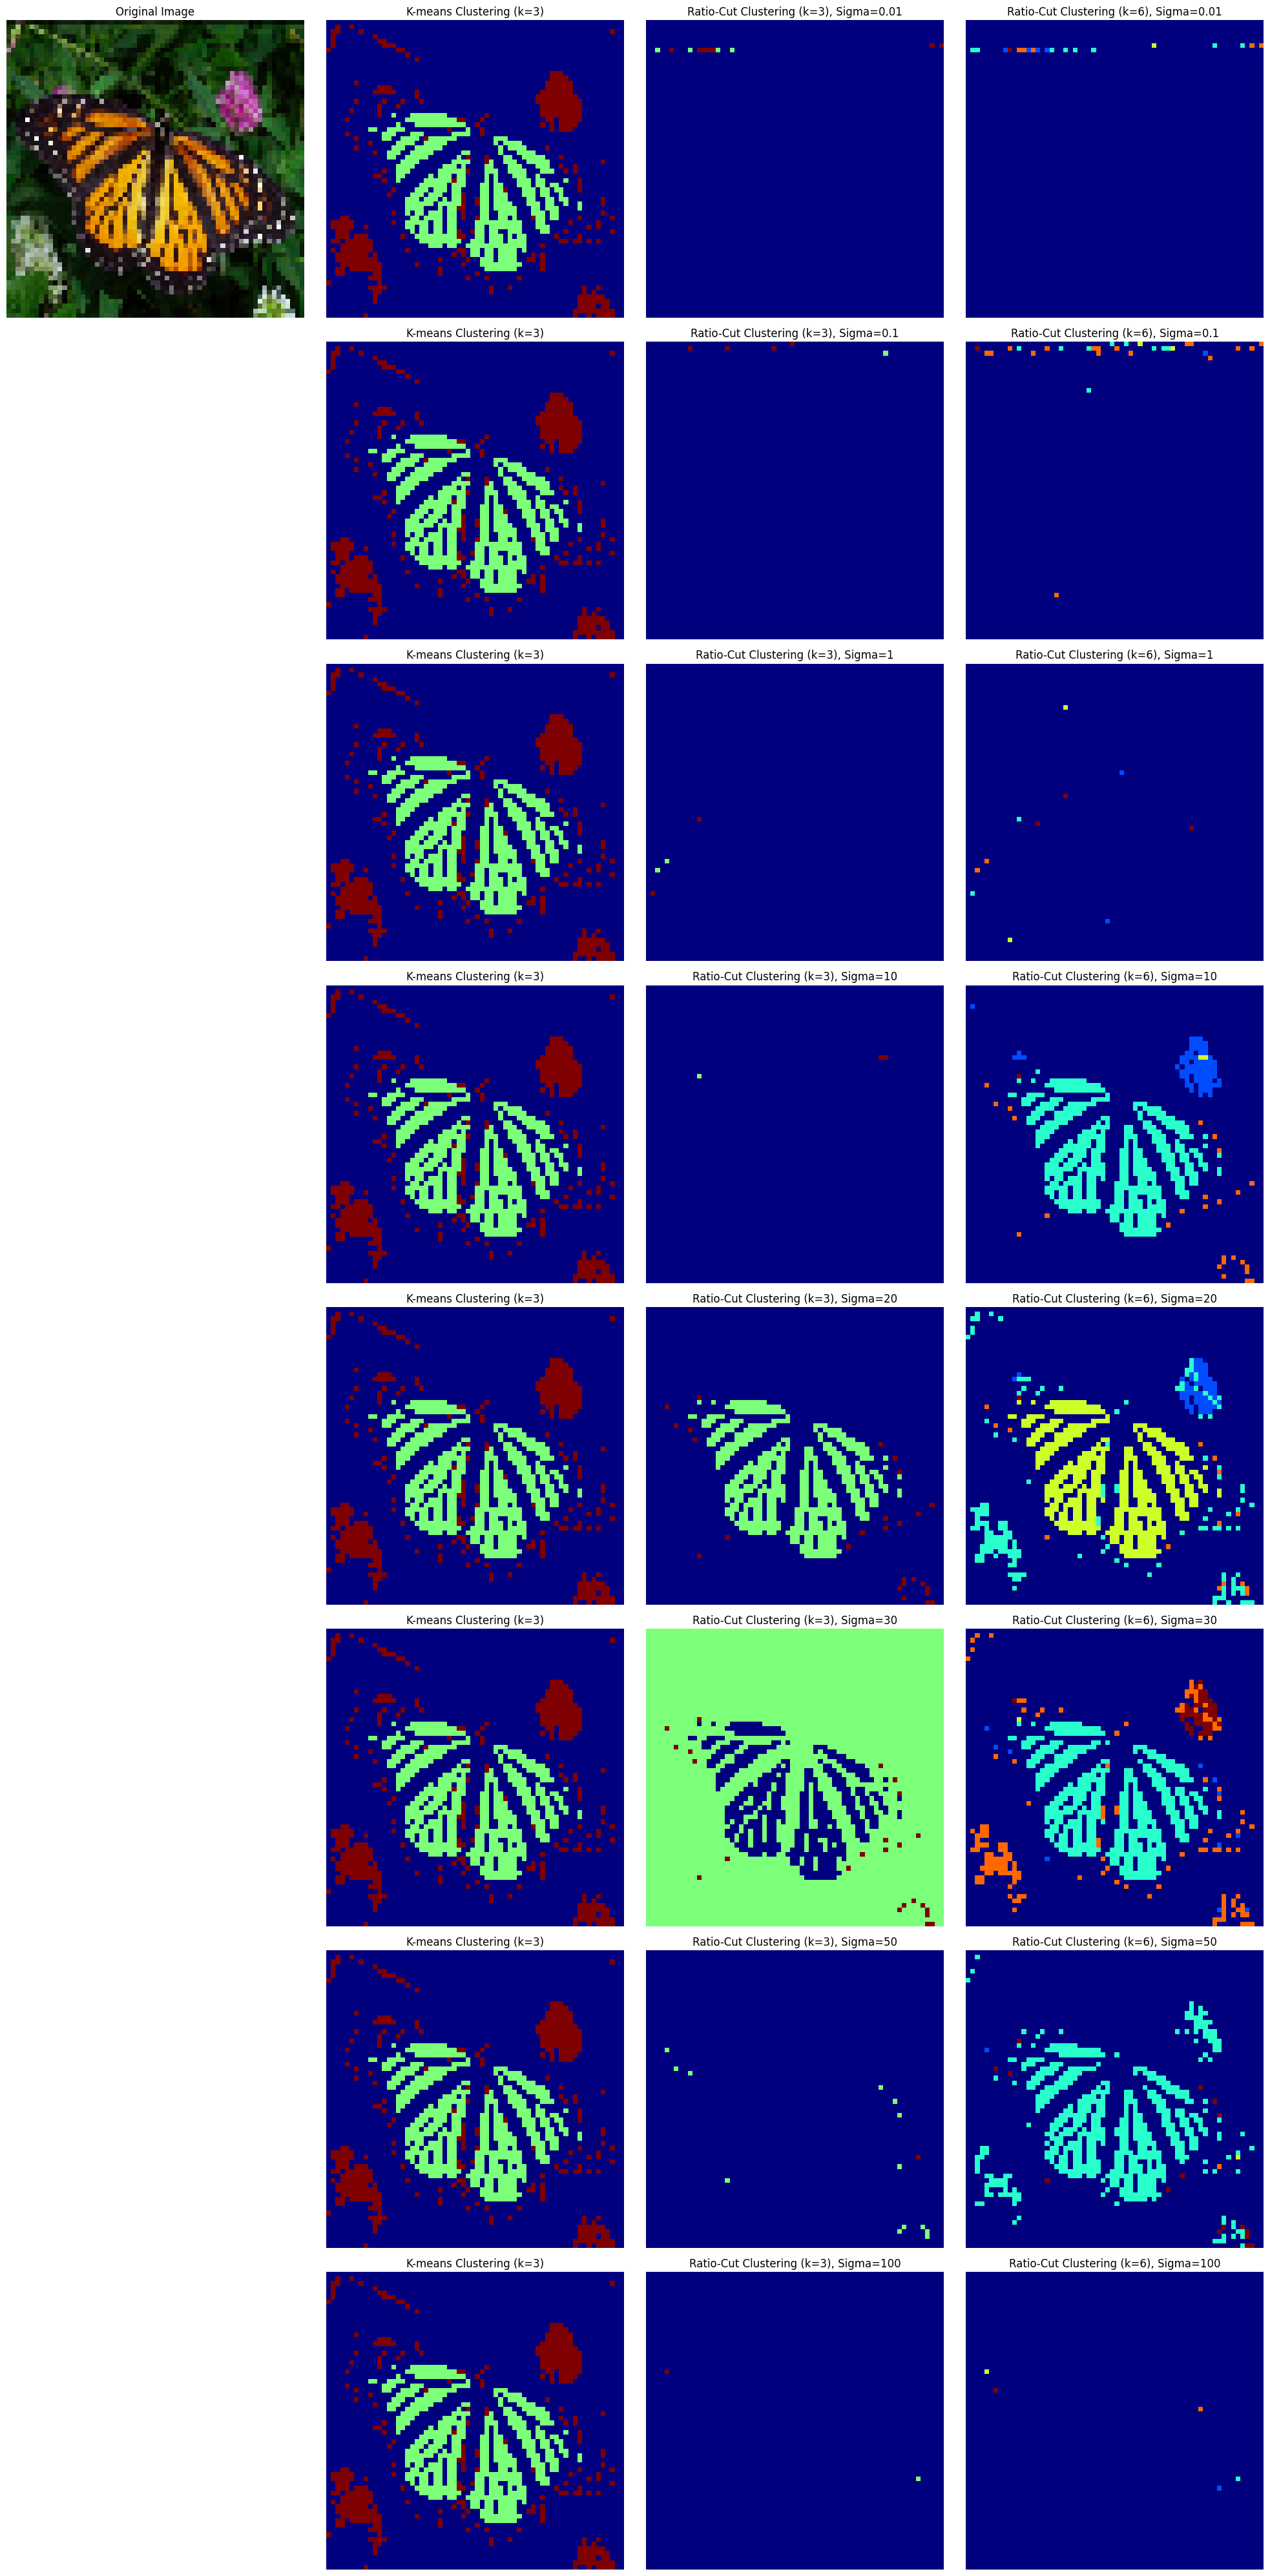

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

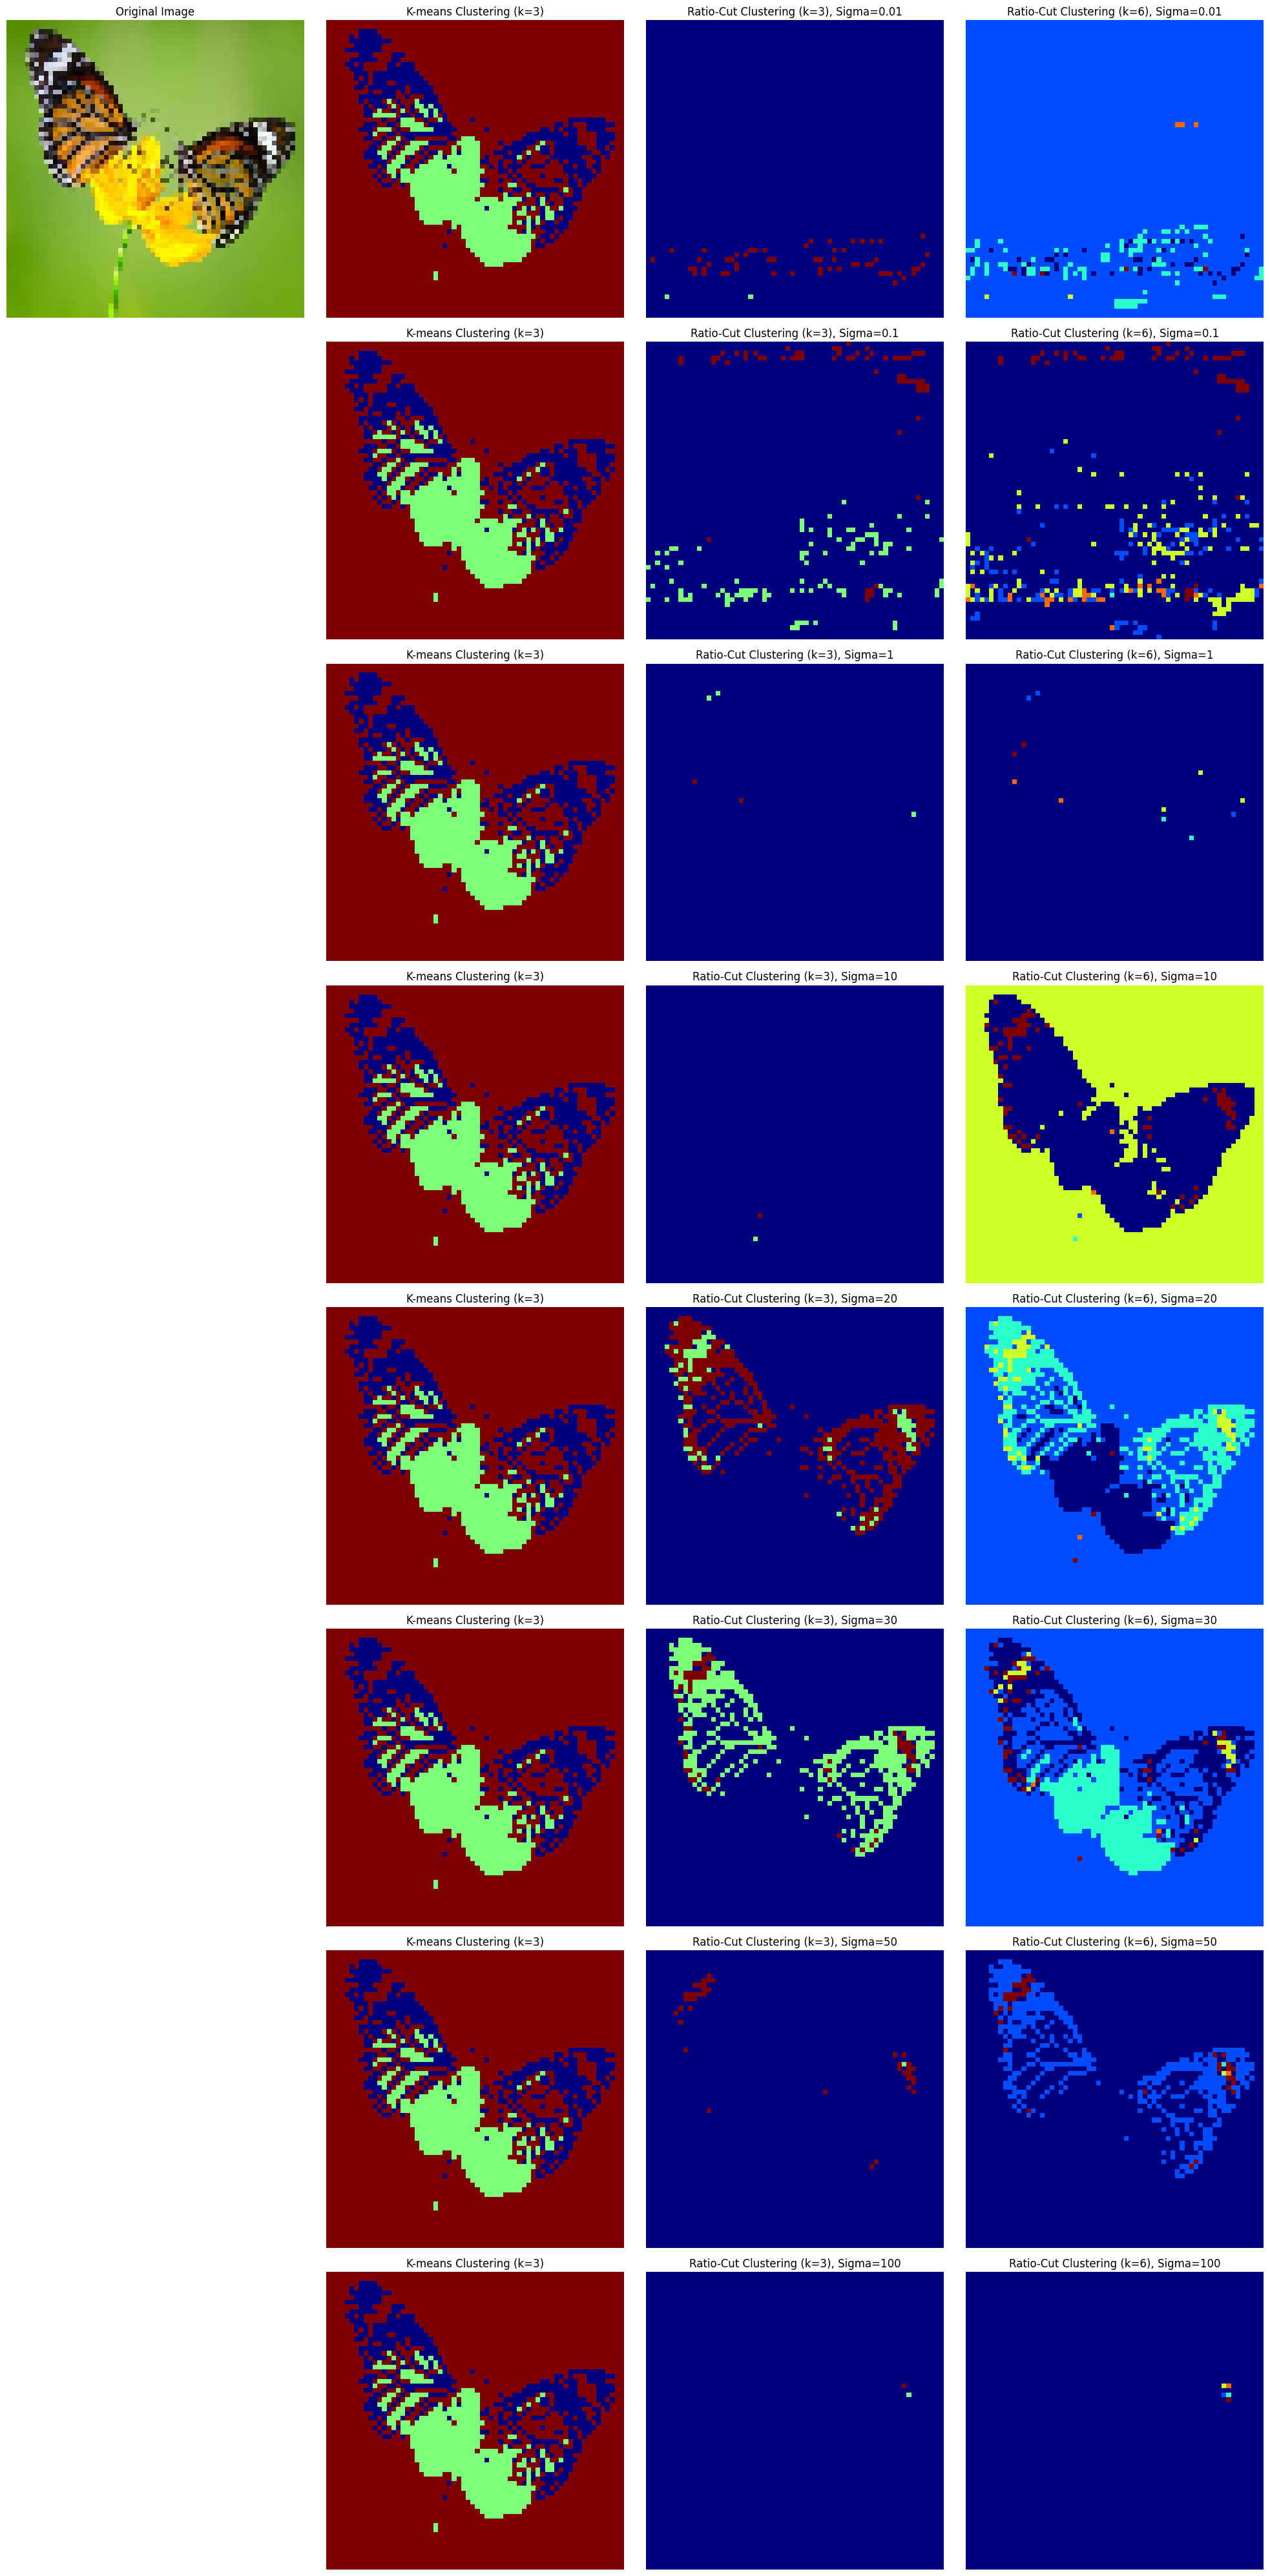

In [35]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import os
import torch
from torchvision.io import read_image
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow

# Function to load and preprocess images
def load_images(image_paths):
    images = []
    for path in image_paths:
        img = read_image(path)
        images.append(img)
    return images
def resize_image(image):
    # Convert the torch tensor to a NumPy array
    image_np = image.permute(1, 2, 0).numpy()
    # Resize the image to 64x64
    resized_image = cv2.resize(image_np, (64, 64))
    return resized_image

def ratio_cut_clustering(image, k, sigma=25):
    # Flatten the image to a 2D array
    pixels = image.reshape((-1, 3)).astype(np.float32)

    # Compute pairwise distance matrix
    pairwise_distances = np.linalg.norm(pixels[:, None] - pixels, axis=2)

    # Compute affinity matrix using Gaussian kernel
    affinity_matrix = np.exp(-pairwise_distances ** 2 / (2.0 * sigma ** 2))

    # Compute degree matrix
    degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))

    # Compute Laplacian matrix
    laplacian_matrix = degree_matrix - affinity_matrix
    #print(laplacian_matrix)


    # Compute eigenvalues and eigenvectors of Laplacian matrix
    eigenvalues, eigenvectors = np.linalg.eigh(laplacian_matrix)

    # Sort eigenvectors based on eigenvalues
    sorted_indices = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:, sorted_indices]


    # Use k smallest eigenvectors as features for clustering
    features = eigenvectors[:, :k]

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0).fit(features)
    labels = kmeans.labels_

    # Reshape labels to match image dimensions
    segmented_image = labels.reshape((64, 64))

    return segmented_image

def kmeans_clustering(image, k):
    # Flatten the image to a 2D array
    pixels = image.reshape((-1, 3))

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pixels)
    labels = kmeans.labels_

    # Reshape labels to match image dimensions
    segmented_image = labels.reshape((64, 64))

    return segmented_image


def compare_segmentation(image_paths, sigmas):
    # Load and preprocess images
    images = load_images(image_paths)
    resized_images = [resize_image(img) for img in images]

    for idx, resized_image in enumerate(resized_images):
        plt.figure(figsize=(20, 5 * len(sigmas)))
        plt.subplot(len(sigmas), 4, 1)
        plt.imshow(resized_image.astype(np.uint8))
        plt.title("Original Image")
        plt.axis('off')

        for i, sigma in enumerate(sigmas):
            # Perform Ratio-Cut clustering with k=3
            ratio_cut_3_clusters = ratio_cut_clustering(resized_image, 3, sigma=sigma)

            # Perform K-means clustering with k=3
            kmeans_3_clusters = kmeans_clustering(resized_image, 3)

            # Perform Ratio-Cut clustering with k=6
            ratio_cut_6_clusters = ratio_cut_clustering(resized_image, 6, sigma=sigma)

            # Perform K-means clustering with k=6
            kmeans_6_clusters = kmeans_clustering(resized_image, 6)

            plt.subplot(len(sigmas), 4, i * 4 + 2)
            plt.imshow(kmeans_3_clusters, cmap='jet')
            plt.title(f"K-means Clustering (k=3)")
            plt.axis('off')

            plt.subplot(len(sigmas), 4, i * 4 + 3)
            plt.imshow(ratio_cut_3_clusters, cmap='jet')
            plt.title(f"Ratio-Cut Clustering (k=3), Sigma={sigma}")
            plt.axis('off')

            plt.subplot(len(sigmas), 4, i * 4 + 4)
            plt.imshow(ratio_cut_6_clusters, cmap='jet')
            plt.title(f"Ratio-Cut Clustering (k=6), Sigma={sigma}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Paths to the images
image_paths = ["/content/drive/MyDrive/data/cv2/image1.jpg", "/content/drive/MyDrive/data/cv2/image2.jpg"]
sigmas = [0.01, 0.1, 1, 10, 20, 30, 50, 100]

# Compare segmentation for the images
compare_segmentation(image_paths, sigmas)


